### QA Exercises on motion for PFM data

#### In this notebook, we'll be testing how different FD thresholds have an impact on reliability estimates for cPFM08. The initial FD threshold is set to 0.3mm (commonly used in developmental fMRI research) so that we can compare the reliability curve generated from the same subject's data with a threshold of 0.2mm FD and 5 contiguous frames from the previous notebook. You can also experiment with other thresholds. Note: there is no contiguous frame threshold for the estimates from this notebook. 

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))
print(PROJECT_ROOT)

import argparse,glob,json,logging,math,os,random,sys,time,warnings
import nibabel as nib
import numpy as np
import pandas as pd
import scipy.io
from IPython.display import SVG, Image, display

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.cm import Set2, tab20
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patheffects as PathEffects
## suppress matplotlib warnings
mpl_logger = logging.getLogger('matplotlib')
mpl_logger.setLevel(logging.WARNING)

from itertools import cycle

/Users/sarahechang/Desktop/research/presentations/FluxPFMWorkshop2026


In [2]:
#paths
sublist_path = PROJECT_ROOT / "01_Reliability" / "scripts" / "sublist.txt"
data_dir = PROJECT_ROOT / "01_Reliability" / "cPFM"
outdir = PROJECT_ROOT / "03_QA" / "figures"

#parameters
subid = "cPFM08"
task="rest"
fd_thresh = 0.3
TR = 1.1

#plotting parameters for later
subids = []
studies = []
grouping = []
plot_groups = []
grouping_dict = {}

with open(sublist_path, 'r') as file:
    entries = [line.rstrip('\n') for line in file]
    for x in entries:
        theid = x.split()[0]
        subids.append(theid)
        thestudy = x.split()[1]
        studies.append(thestudy)
        thegroup = x.split()[2]
        grouping.append(thegroup)
        if thegroup != '999':
            if thegroup not in grouping_dict:
                grouping_dict[thegroup] = [theid]
                plot_groups.append(thestudy)
            else:
                grouping_dict[thegroup].append(theid)

sys.path.append(str(PROJECT_ROOT / "03_QA"))
from scripts.RestReliability_Flux2026_motion import (
    create_raw_data,
    create_true,
    plot_corrs,
    get_corrs,
    clean_dict,
    plot_final
)

In [3]:
display(Image(filename='/Users/sarahechang/Desktop/research/presentations/FluxPFMWorkshop2026/01_Reliability/notebooks/images/cPFM08_reliability_true60min_0.2FD_5contig_12visits_1000_Iterations.png', width=750, height=450))

#### With 15 minutes of true time, changing the FD to 0.3FD increases the amount of time per subject, but lowers your reliability, which never reaches 0.9. Using 15 minutes of true time, reliability with 15 minutes is around 0.7.

In [4]:
display(Image(filename='/Users/sarahechang/Desktop/research/presentations/FluxPFMWorkshop2026/03_QA/notebooks/images/cPFM08_reliability_true15min_0.3FD_nocontig_12visits_1000_Iterations.png', width=800, height=600))

In [8]:
# Motion censor and concatenate Gordon parcel timeseries data
num_of_sessions = 1
raw_concatenated_data = create_raw_data(subid, data_dir, task, fd_thresh, TR, num_of_sessions)


----Creating all visit, concatenated RAW data for cPFM08----
Processing 1 sessions:
ses-20180708_task-rest_DCANBOLDProc_v4.0.0_Gordon_6.0mm_SMOOTHED.ptseries.nii
Shape of ptseries data array (parcels, frames collected): (333, 1638)
Reading motion file: ses-20180708_task-rest_motion_numbers.mat
   -Original frames: 1638
   -Frames after censoring: 1338
      
      
Total visits for sub-cPFM08: 1
Concatenated/Censored data shape (parcels, frames): (333, 1338)
Censored data in time: 00Hours 24Min 31Sec


In [11]:
# Divide the concatenated data into a high confidence and test subsets. 
# Calculate correlation between each subset. Do this 1000 times.
# The more censored data in time, the longer this takes to run.

#Define the length of the 'high confidence' subset in minutes.
truetime=5
all_data_dict = {'all_times': []}
all_data_dict[subid] = []
update_thresh=50
rands=1000

print(f'\nRunning randomized iterations. (terminal update every {update_thresh})')
for i in range(1, rands + 1):
    if i % update_thresh == 0:
        print(f' -Iteration: {i}')
    hour_array, test_data, true_data_zmat, max_minutes = create_true(raw_concatenated_data, truetime, TR)
    all_data_dict, corr_value_list = get_corrs(true_data_zmat,test_data, max_minutes, all_data_dict, TR, subid)

#check how much high confidence data you're using
seconds_true = math.floor(hour_array.shape[1] * TR)
hours_true = seconds_true // 3600
minutes_true = (seconds_true % 3600) // 60
seconds_true = seconds_true % 60
print('True data in time: {:02d}Hours {:02d}Min {:02d}Seconds'.format(hours_true, minutes_true, seconds_true))

#check how much test data you're using
seconds_test = math.floor(test_data.shape[1] * TR)
hours_test = seconds_test // 3600
minutes_test = (seconds_test % 3600) // 60
seconds_test = seconds_test % 60
print('Test data in time: {:02d}Hours {:02d}Min {:02d}Seconds'.format(hours_test, minutes_test, seconds_test))


Running randomized iterations. (terminal update every 50)
 -Iteration: 50
 -Iteration: 100
 -Iteration: 150
 -Iteration: 200
 -Iteration: 250
 -Iteration: 300
 -Iteration: 350
 -Iteration: 400
 -Iteration: 450
 -Iteration: 500
 -Iteration: 550
 -Iteration: 600
 -Iteration: 650
 -Iteration: 700
 -Iteration: 750
 -Iteration: 800
 -Iteration: 850
 -Iteration: 900
 -Iteration: 950
 -Iteration: 1000
True data in time: 00Hours 05Min 00Seconds
Test data in time: 00Hours 19Min 31Seconds


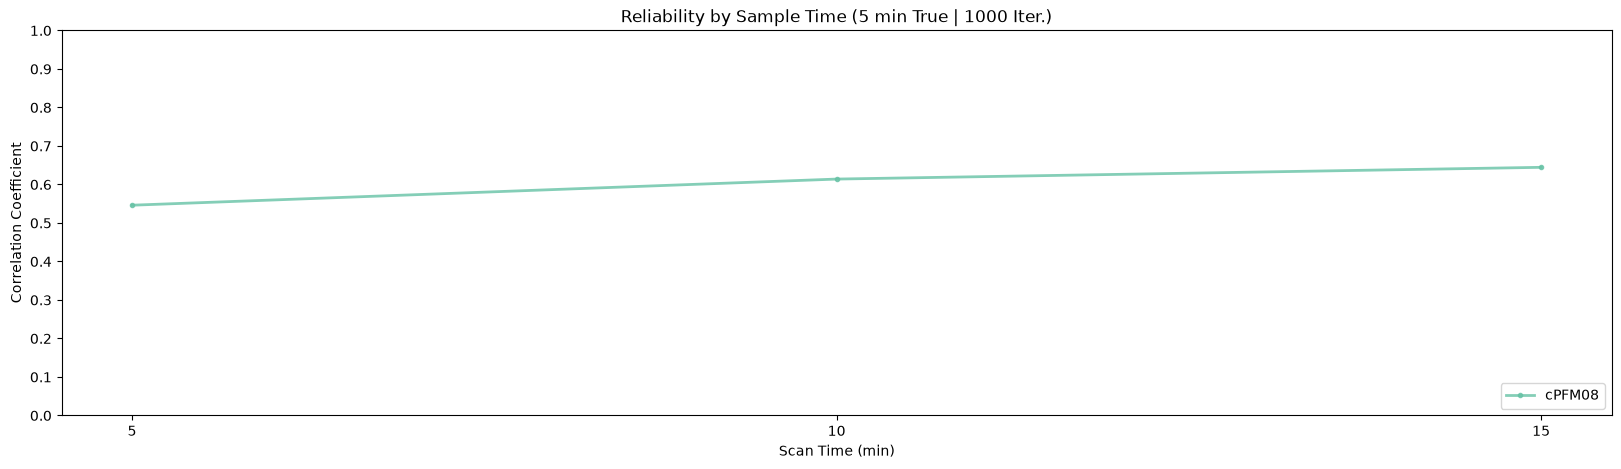

In [12]:
# Step 4.3: Clean and plot correlation values. 
all_data_dict = clean_dict(all_data_dict)
plot_final(all_data_dict, outdir, subid, truetime, fd_thresh, rands, num_of_sessions, subids)

Most work on the test retest reliability of fMRI data has been conducted in adults, and levels of motion are higher on average in kids compared to adults. Here we find that a stricter FD threshold does have an impact on the reliability curves (from Pearson's correlation). 